<a href="https://colab.research.google.com/github/lorenabao/Basics-Python/blob/main/challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extractor de Inteligencia Financiera Basado en Tweets

### **Objetivo**
Construir un script de Python que procese un dataset sintético de tweets financieros, extraiga información clave (entidades y sentimiento), estructure estos datos en un DataFrame limpio y realice un análisis para descubrir tendencias de sentimiento.

### **Paso 1: Configuración y Carga de Datos**

Primero, importa las librerías necesarias y carga el dataset de tweets `tweets.json`.

### **Paso 2: Inicializar los Pipelines de NLP**

Necesitarás dos pipelines de Hugging Face para esta tarea: una pipeline de **Análisis de Sentimiento** y una pipeline de **Reconocimiento de Entidades Nombradas (NER)**.

### **Paso 3: Construir la Función Principal de Procesamiento**

Esta función procesará una única fila de tweet. Realizará un análisis de sentimiento, ejecutará NER para extraer entidades y luego devolverá una **lista de diccionarios**, donde cada diccionario representa una fila final y estructurada. Tienes que obtener una combinación única por cada persona, localidad y organización del tweet. Ejemplo:

- Tweet:
    ```text
    NVIDIA ($NVDA) is on another tear, hitting a new all-time high. The demand for their AI chips seems insatiable. Jensen Huang has built an absolute monster in Santa Clara. #AI #Investing #Semiconductors
    ```
- Entidades detectadas por la pipeline NER:
    - Personas: Jensen Huang
    - Orgnaizaciones: NVIDIA, NVDA
    - Localidades: Santa Clara

- Diccionario final:
    ```json
    [
        {
            "person": "Jensen Huang",
            "company": "NVIDIA",
            "location": "Santa Clara"
        },
        {
            "person": "Jensen Huang",
            "company": "NVDA",
            "location": "Santa Clara"
        }
    ]
    ```

### **Paso 4: Ejecutar el Pipeline de Procesamiento**
Procesa todos los tweets y monta el DataFrame final.

### **Paso 5: Analizar los Datos Procesados**

Ahora que tienes un dataset estructurado, puedes extraer insights. Responde las siguientes preguntas usando el DataFrame `df_master`.

#### **Pregunta 1: ¿De quién y de qué se habla más?**
Identifica las 15 empresas y personas mencionadas con más frecuencia en el dataset.

#### **Pregunta 2: ¿Cuál es la distribución general de sentimientos?**
Muestra el recuento de tweets POSITIVOS vs. NEGATIVOS en todo el dataset procesado.

#### **Pregunta 3: ¿Qué empresas tienen el mayor y menor impacto de sentimiento?**
El sentimiento simple no es suficiente; el engagement (interacción) importa. Crea una puntuación de "impacto de sentimiento" que pondere el sentimiento por los 'likes' y 'retweets' del tweet. Un tweet positivo con muchos 'likes' debería tener un impacto mucho mayor que un tweet negativo con cero 'likes'.

Calcula esta puntuación y encuentra las 15 empresas con el mayor y menor impacto de sentimiento promedio.

#### **Pregunta 4: ¿Qué individuos tienen el mayor y menor impacto de

*   List item
*   List item

sentimiento?**
Usando la misma puntuación de "impacto de sentimiento", encuentra los 15 individuos con el mayor y menor impacto de sentimiento promedio.

In [1]:
!pip -q install transformers==4.43.3 torch --upgrade

import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 64.7 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving tweets.json to tweets.json


In [5]:
df_raw = pd.read_json("tweets.json")

print("Columnas:", df_raw.columns.tolist())
df_raw.head()

Columnas: ['handler', 'tweet', 'likes', 'retweets', 'responses']


,handler,tweet,likes,retweets,responses
0,@TechInvestor_Pro,"NVIDIA ($NVDA) is on another tear, hitting a n...",2371,473,121
1,@MarketPulseNews,Apple ($AAPL) investors getting a bit nervous ...,462,71,39
2,@satyanadella,Empowering developers is at the core of our mi...,22487,4513,1198
3,@sundarpichai,Excited to kick off Google I/O next week! We'l...,18194,3108,947
4,@amazon,We're continuing to invest in building the fut...,9788,1205,453


In [21]:
df = df_raw.copy()
df.head()

,handler,tweet,likes,retweets,responses
0,@TechInvestor_Pro,"NVIDIA ($NVDA) is on another tear, hitting a n...",2371,473,121
1,@MarketPulseNews,Apple ($AAPL) investors getting a bit nervous ...,462,71,39
2,@satyanadella,Empowering developers is at the core of our mi...,22487,4513,1198
3,@sundarpichai,Excited to kick off Google I/O next week! We'l...,18194,3108,947
4,@amazon,We're continuing to invest in building the fut...,9788,1205,453


In [20]:
sent_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
ner_pipe  = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [24]:
TICKER_RE = re.compile(r"\$[A-Za-z][A-Za-z0-9]{0,5}")

def extract_tickers(text):
    return [t.replace("$","") for t in TICKER_RE.findall(text or "")]

def map_entity_group(label):
    label = (label or "").upper()
    if label.startswith("PER"): return "person"
    if label.startswith("ORG"): return "company"
    if label.startswith("LOC"): return "location"
    return None

def sentiment_to_score(label):
    lab = (label or "").upper()
    if "POS" in lab: return 1
    if "NEG" in lab: return -1
    return 0

In [27]:
df["tweet_id"] = range(len(df_raw))

In [28]:
def process_one_tweet(row):
    text = row["tweet"]   # <--- ahora usa la columna original
    if not isinstance(text, str) or not text.strip():
        return []

    # Sentimiento
    s = sent_pipe(text)[0]
    sent_label = s.get("label", "NEUTRAL")
    sent_score = sentiment_to_score(sent_label)

    # NER
    ents = ner_pipe(text)
    persons, companies, locations = set(), set(), set()
    for e in ents:
        mapped = map_entity_group(e.get("entity_group") or e.get("entity"))
        if mapped == "person":   persons.add(e.get("word","").strip())
        elif mapped == "company": companies.add(e.get("word","").strip())
        elif mapped == "location": locations.add(e.get("word","").strip())

    # Tickers
    for tk in extract_tickers(text):
        companies.add(tk)

    persons_list   = list(persons)   if persons   else [None]
    companies_list = list(companies) if companies else [None]
    locations_list = list(locations) if locations else [None]

    rows = []
    for p in persons_list:
        for c in companies_list:
            for l in locations_list:
                rows.append({
                    "tweet_id": row["tweet_id"],
                    "user": row["handler"],
                    "text": text,
                    "person": p,
                    "company": c,
                    "location": l,
                    "likes": int(row["likes"]),
                    "retweets": int(row["retweets"]),
                    "responses": int(row["responses"]),
                    "sentiment_label": sent_label,
                    "sentiment_score": sent_score
                })
    return rows

In [29]:
rows = []
for _, r in df.iterrows():
    rows.extend(process_one_tweet(r))

df_master = pd.DataFrame(rows)
print("Filas en df_master:", len(df_master))
df_master.head()

Filas en df_master: 845


,tweet_id,user,text,person,company,location,likes,retweets,responses,sentiment_label,sentiment_score
0,0,@TechInvestor_Pro,"NVIDIA ($NVDA) is on another tear, hitting a n...",Jensen Huang,##VIDIA,Santa Clara,2371,473,121,POSITIVE,1
1,0,@TechInvestor_Pro,"NVIDIA ($NVDA) is on another tear, hitting a n...",Jensen Huang,NVDA,Santa Clara,2371,473,121,POSITIVE,1
2,1,@MarketPulseNews,Apple ($AAPL) investors getting a bit nervous ...,Tim Cook,AAPL,Shanghai,462,71,39,NEGATIVE,-1
3,1,@MarketPulseNews,Apple ($AAPL) investors getting a bit nervous ...,Tim Cook,SupplyC,Shanghai,462,71,39,NEGATIVE,-1
4,1,@MarketPulseNews,Apple ($AAPL) investors getting a bit nervous ...,Tim Cook,Apple,Shanghai,462,71,39,NEGATIVE,-1


Top 15 compañías:
 company
Apple        16
NVDA         14
Fed          11
AMZN         11
GOOGL        10
Amazon        8
MSFT          8
AAPL          8
META          6
Google        6
Tesla         6
Microsoft     6
Meta          5
Big Tech      4
Starbucks     4
Name: count, dtype: int64 

Top 15 personas:
 person
Tim Cook          7
Jamie Dimon       6
Z                 5
Jensen Huang      4
Warren Buffett    4
Bull              4
##ck Tan          3
Bob Iger          3
Blackwell         3
Diamond           3
Ho                3
##dar Picha       2
Sun               2
Lisa Su           2
##lo              2
Name: count, dtype: int64


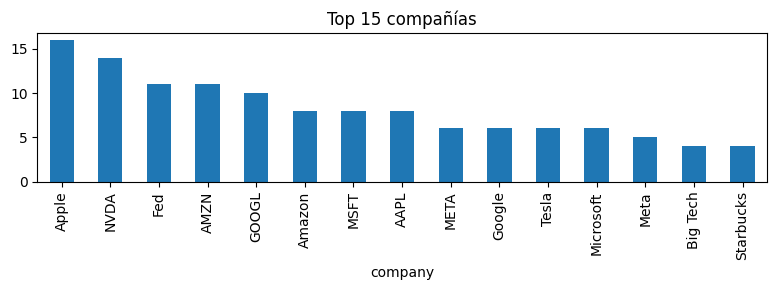

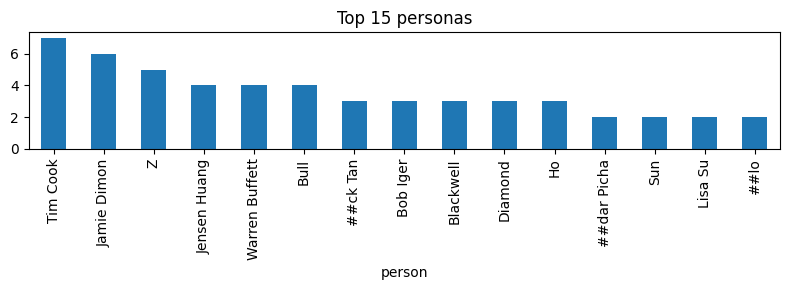

In [30]:
# Pregunta 1: ¿De quién y de qué se habla más?

def top_counts(series, k=15):
    return (series.dropna()
                  .astype(str)
                  .str.strip()
                  .replace({"": np.nan})
                  .dropna()
                  .value_counts()
                  .head(k))

top_companies = top_counts(df_master["company"], 15)
top_persons   = top_counts(df_master["person"], 15)

print("Top 15 compañías:\n", top_companies, "\n")
print("Top 15 personas:\n", top_persons)

top_companies.plot(kind="bar", figsize=(8,3), title="Top 15 compañías"); plt.tight_layout(); plt.show()
top_persons.plot(kind="bar", figsize=(8,3), title="Top 15 personas"); plt.tight_layout(); plt.show()

sentiment_label
POSITIVE    573
NEGATIVE    272
Name: count, dtype: int64


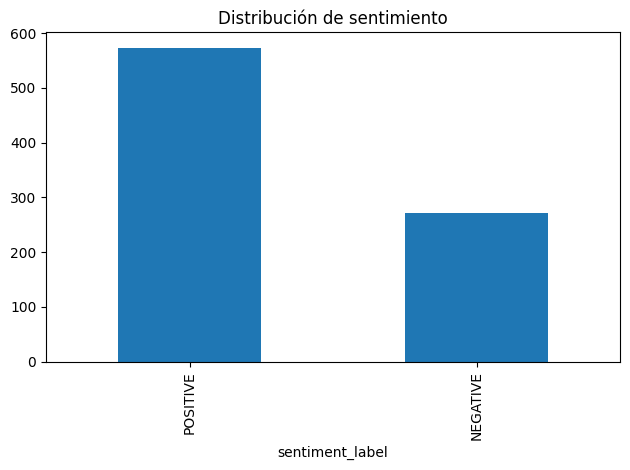

In [31]:
# Pregunta 2: ¿Cuál es la distribución general de sentimientos?

sent_dist = df_master["sentiment_label"].value_counts()
print(sent_dist)
sent_dist.plot(kind="bar", title="Distribución de sentimiento"); plt.tight_layout(); plt.show()

Top 15 compañías por impacto promedio:
 company
Stars              760343.000000
Spice Latte        540204.000000
##R                416557.000000
P                  275260.500000
MacBookAir         141590.000000
MacBook Air        141590.000000
Starlink           138903.000000
Community Notes    121213.000000
WWDC24             107589.000000
##C                107589.000000
Artemis            106224.000000
BlueO              103574.000000
Apple Store         89287.000000
Netflix             85524.000000
SpaceX              70094.666667
Name: sentiment_impact, dtype: float64 

Bottom 15 compañías por impacto promedio:
 company
Teams                -14044.0
GartnerH             -14129.0
##co                 -15749.0
##verning Council    -20340.0
Go                   -20340.0
ECB                  -20340.0
FTC                  -29746.0
SEC                  -30725.5
SkyMiles             -31303.0
TargetStyle          -31352.0
NPR                  -32355.0
X                    -39287.0
Black

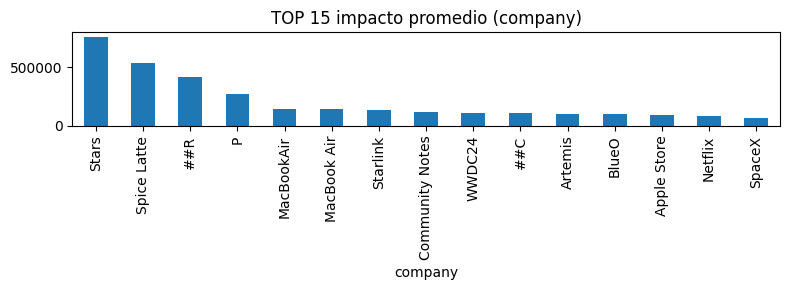

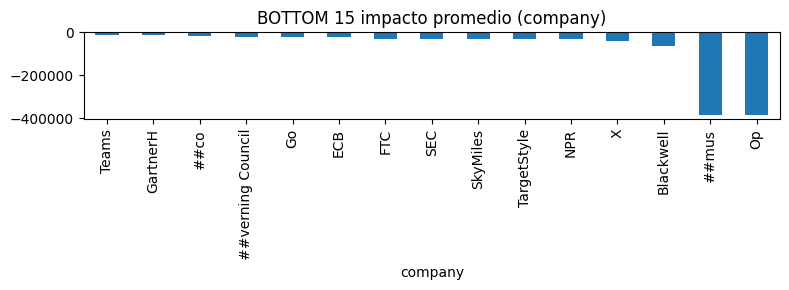

In [32]:
# Pregunta 3: ¿Qué empresas tienen el mayor y menor impacto de sentimiento?

df_master["engagement"] = 1 + df_master["likes"] + df_master["retweets"] + df_master["responses"]
df_master["sentiment_impact"] = df_master["sentiment_score"] * df_master["engagement"]

comp_impact = (df_master.dropna(subset=["company"])
                         .groupby("company")["sentiment_impact"]
                         .mean()
                         .sort_values(ascending=False))

print("Top 15 compañías por impacto promedio:\n", comp_impact.head(15), "\n")
print("Bottom 15 compañías por impacto promedio:\n", comp_impact.tail(15))

comp_impact.head(15).plot(kind="bar", figsize=(8,3), title="TOP 15 impacto promedio (company)"); plt.tight_layout(); plt.show()
comp_impact.tail(15).plot(kind="bar", figsize=(8,3), title="BOTTOM 15 impacto promedio (company)"); plt.tight_layout(); plt.show()

Top 15 personas por impacto promedio:
 person
M               416557.0
Travis Scott    364104.0
Diab            106224.0
Fe              103574.0
G               103574.0
##lo             60723.5
##so Blanco      59703.0
Que              59703.0
Chip             57045.0
##erberg         22249.0
Zuck             22249.0
Nelson Peltz     19323.0
Sam Altman       17686.0
F                15223.0
Benio            14830.0
Name: sentiment_impact, dtype: float64 

Bottom 15 personas por impacto promedio:
 person
Lisa Su         1091.000000
Sun              485.000000
##dar Picha      485.000000
Andy Jassy       434.000000
Jeff Bezos       434.000000
Tim Cook         -86.428571
Marc Benioff    -332.000000
Bull            -383.000000
Disney          -859.000000
Alex Karp      -1457.000000
##ck Tan       -1980.000000
Ho             -1980.000000
Blackwell      -6187.000000
Diamond        -6187.000000
Mike Wilson    -9871.000000
Name: sentiment_impact, dtype: float64


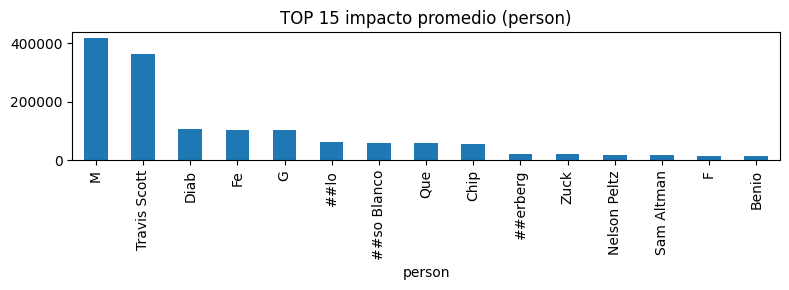

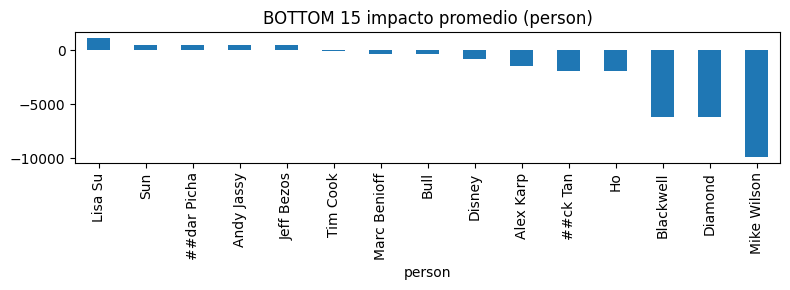

In [33]:
# Pregunta 4: ¿Qué individuos tienen el mayor y menor impacto de sentimiento?

pers_impact = (df_master.dropna(subset=["person"])
                         .groupby("person")["sentiment_impact"]
                         .mean()
                         .sort_values(ascending=False))

print("Top 15 personas por impacto promedio:\n", pers_impact.head(15), "\n")
print("Bottom 15 personas por impacto promedio:\n", pers_impact.tail(15))

pers_impact.head(15).plot(kind="bar", figsize=(8,3), title="TOP 15 impacto promedio (person)"); plt.tight_layout(); plt.show()
pers_impact.tail(15).plot(kind="bar", figsize=(8,3), title="BOTTOM 15 impacto promedio (person)"); plt.tight_layout(); plt.show()